# Hardware & Accuracy Test Runner

This cell runs SMT synthesis, hardware synthesis, and cocotb accuracy tests for `FP32` and `MXINT8` addition/multiplication - for both `subcomponents` and `combined` variants. 

In [ ]:
import os
import re
import sys
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while root != root.parent:
        if (root / "src" / "synthesis_driver.py").exists() and (root / "accuracy_tests" / "Makefile").exists():
            return root
        root = root.parent
    raise RuntimeError("Could not locate repo root containing src/synthesis_driver.py and accuracy_tests/Makefile")


ROOT = find_repo_root()
ACC_DIR = ROOT / "accuracy_tests"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.run_vitis_hls import parse_reports

# -------- Knobs --------
RUN_IMPL = True
RUN_ACCURACY = True
RUN_FLOPOCO_ACCURACY = True
ENABLE_DIRECTED_IO = True
NUM_ITERATIONS = 30
SOLVER_TIMEOUT_SECONDS = 15
SHOW_FULL_LOG = False
TAIL_LINES = 200

# -------- Jobs --------
SYNTH_JOBS = [
    {
        "name": "mxint8_add_subcomponents",
        "target": "mxint8_add",
        "component": "full_sum",
        "op": "Addition",
        "dtype": "MXINT8",
        "variant": "Subcomponents",
        "soln": "solution_mxint8addition_full_sum",
        "top": "add_full_sum",
        "base": "HLS",
    },
    {
        "name": "mxint8_add_combined",
        "target": "mxint8_add",
        "component": "full_sum_combined",
        "op": "Addition",
        "dtype": "MXINT8",
        "variant": "Combined",
        "soln": "solution_mxint8addition_full_sum_combined",
        "top": "add_full_sum",
        "base": "HLS",
    },
    {
        "name": "mxint8_mul_subcomponents",
        "target": "mxint8_mul",
        "component": "full_product",
        "op": "Multiplication",
        "dtype": "MXINT8",
        "variant": "Subcomponents",
        "soln": "solution_mxint8multiplication_full_product",
        "top": "mult_mxint_full_product",
        "base": "HLS",
    },
    {
        "name": "mxint8_mul_combined",
        "target": "mxint8_mul",
        "component": "full_product_combined",
        "op": "Multiplication",
        "dtype": "MXINT8",
        "variant": "Combined",
        "soln": "solution_mxint8multiplication_full_product_combined",
        "top": "mult_mxint_full_product",
        "base": "HLS",
    },
    {
        "name": "fp32_add_subcomponents",
        "target": "fp32_add",
        "component": "fp32_full_sum",
        "op": "Addition",
        "dtype": "FP32",
        "variant": "Subcomponents",
        "soln": "solution_fp32addition_fp32_full_sum",
        "top": "fp32_sum",
        "base": "HLS",
    },
    {
        "name": "fp32_add_combined",
        "target": "fp32_add",
        "component": "fp32_full_sum_combined",
        "op": "Addition",
        "dtype": "FP32",
        "variant": "Combined",
        "soln": "solution_fp32addition_fp32_full_sum_combined",
        "top": "fp32_sum",
        "base": "HLS",
    },
    {
        "name": "fp32_mul_subcomponents",
        "target": "fp32_mul",
        "component": "full_product",
        "op": "Multiplication",
        "dtype": "FP32",
        "variant": "Subcomponents",
        "soln": "solution_fp32multiplication_full_product",
        "top": "fp32_full_mul",
        "base": "HLS",
    },
    {
        "name": "fp32_mul_combined",
        "target": "fp32_mul",
        "component": "full_product_combined",
        "op": "Multiplication",
        "dtype": "FP32",
        "variant": "Combined",
        "soln": "solution_fp32multiplication_full_product_combined",
        "top": "fp32_full_mul",
        "base": "HLS",
    },
]

FLOPOCO_ACCURACY_JOBS = [
    {
        "name": "fp32_add_flopoco",
        "op": "Addition",
        "dtype": "FP32",
        "variant": "Flopoco",
        "soln": "solution_fp32addition_flopoco",
        "top": "fp32_sum_flopoco",
        "module": "tests.addition.test_fp32_adder",
        "variant_env": "FP32_ADD_VARIANT",
        "variant_value": "flopoco",
        "base": "FLOPOCO",
    },
    {
        "name": "fp32_mul_flopoco",
        "op": "Multiplication",
        "dtype": "FP32",
        "variant": "Flopoco",
        "soln": "solution_fp32multiplication_flopoco",
        "top": "fp32_full_mul_flopoco",
        "module": "tests.multiplication.test_fp32_multiplier",
        "variant_env": "FP32_MUL_VARIANT",
        "variant_value": "flopoco",
        "base": "FLOPOCO",
    },
]


def tail(text: str, lines: int) -> str:
    parts = (text or "").splitlines()
    return "\n".join(parts[-lines:])


def extract_metrics(text: str) -> dict:
    metrics = {}
    for raw in (text or "").splitlines():
        line = raw.strip()

        m_ran = re.search(r"Ran\s+\d+\s+(?:test\s+)?cases?\s+\(skipped\s+\d+\)", line)
        if m_ran:
            metrics["ran"] = m_ran.group(0)

        if "Percent Within" in line:
            metrics.setdefault("percent_within", []).append(line)
        if "ULP avg=" in line:
            metrics["ulp_summary"] = line
        if "Exact " in line and "ULP" in line:
            metrics["ulp_exact"] = line
        if "Within " in line and "relative error" in line:
            metrics.setdefault("within_rel", []).append(line)
        if "Max Absolute Error:" in line:
            metrics.setdefault("max_abs", []).append(line)
        if "Average Absolute Error:" in line:
            metrics.setdefault("avg_abs", []).append(line)
        if "99th Percentile" in line:
            metrics.setdefault("p99", []).append(line)
        if "95th Percentile" in line:
            metrics.setdefault("p95", []).append(line)
    return metrics


def parse_accuracy_rc_from_driver(text: str):
    if "[SUCCESS] Accuracy run completed successfully." in text:
        return 0
    m = re.search(r"Accuracy run failed with return code\s+(\d+)", text)
    if m:
        return int(m.group(1))
    return None


def _parse_ran(line):
    m = re.search(r"Ran\s+(\d+)\s+(?:test\s+)?cases?\s+\(skipped\s+(\d+)\)", line or "")
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)


def _parse_value_after_colon(line):
    m = re.search(r":\s*(-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", line or "")
    return float(m.group(1)) if m else np.nan


def _parse_percent_after_colon(line):
    m = re.search(r":\s*([0-9]+(?:\.[0-9]+)?)\s*%", line or "")
    return float(m.group(1)) if m else np.nan


def _parse_ulp_summary(line):
    m = re.search(r"ULP avg=([0-9]+(?:\.[0-9]+)?),\s*p99=(\d+),\s*max=(\d+)", line or "")
    if not m:
        return (np.nan, np.nan, np.nan)
    return (float(m.group(1)), int(m.group(2)), int(m.group(3)))


def _parse_ulp_exact(line):
    vals = re.findall(r"([0-9]+(?:\.[0-9]+)?)\s*%", line or "")
    return tuple(float(v) for v in vals[:4]) if len(vals) >= 4 else (np.nan, np.nan, np.nan, np.nan)


print(f"Running unified synthesis+accuracy pipeline for {len(SYNTH_JOBS)} synthesis jobs")
results = []

for job in SYNTH_JOBS:
    print(f"\n=== Pipeline run: {job['name']} ===")

    env = os.environ.copy()
    env.update(
        {
            "SYNTH_TARGET": job["target"],
            "SYNTH_COMPONENT": job["component"],
            "SYNTH_RUN_IMPL": "1" if RUN_IMPL else "0",
            "SYNTH_RUN_ACCURACY": "1" if RUN_ACCURACY else "0",
            "SYNTH_ENABLE_DIRECTED_IO": "1" if ENABLE_DIRECTED_IO else "0",
            "SYNTH_NUM_ITERATIONS": str(NUM_ITERATIONS),
            "SYNTH_SOLVER_TIMEOUT": str(SOLVER_TIMEOUT_SECONDS),
        }
    )

    proc = subprocess.run(
        [sys.executable, "-m", "src.synthesis_driver"],
        cwd=ROOT,
        env=env,
        text=True,
        capture_output=True,
    )

    stdout = proc.stdout or ""
    stderr = proc.stderr or ""

    if SHOW_FULL_LOG:
        print(stdout)
        if stderr:
            print("\n[stderr]\n" + stderr)
    else:
        print(tail(stdout, TAIL_LINES))
        if stderr:
            print("\n[stderr tail]\n" + tail(stderr, TAIL_LINES))

    metrics = extract_metrics(stdout)
    if not metrics and stderr:
        metrics = extract_metrics(stderr)

    acc_rc = parse_accuracy_rc_from_driver(stdout) if RUN_ACCURACY else None

    results.append(
        {
            "name": job["name"],
            "op": job["op"],
            "dtype": job["dtype"],
            "variant": job["variant"],
            "soln": job["soln"],
            "top": job["top"],
            "base": job["base"],
            "pipeline_returncode": proc.returncode,
            "returncode": acc_rc,
            "metrics": metrics,
        }
    )

if RUN_ACCURACY and RUN_FLOPOCO_ACCURACY:
    print("\nRunning FLOPOCO accuracy-only jobs")
    for job in FLOPOCO_ACCURACY_JOBS:
        print(f"\n=== Accuracy run: {job['name']} ===")

        rtl_dir = ROOT / "results" / job["base"] / job["soln"] / "verilog_out"
        if not rtl_dir.exists():
            print(f"Skipping {job['name']} (missing RTL dir: {rtl_dir})")
            rc = None
            metrics = {}
        elif shutil.which("ghdl") is None:
            print(f"Skipping {job['name']} (ghdl not found in PATH)")
            rc = None
            metrics = {}
        else:
            env = os.environ.copy()
            env.update(
                {
                    "HLS_BASE": str(ROOT / "results" / job["base"]),
                    "HLS_SOLN": job["soln"],
                    "TOPLEVEL": job["top"],
                    "TOPLEVEL_LANG": "vhdl",
                    "SIM": "ghdl",
                    "GHDL_ARGS": "-fsynopsys -fexplicit",
                    "MODULE": job["module"],
                    job["variant_env"]: job["variant_value"],
                }
            )

            proc = subprocess.run(
                ["make", "-f", "Makefile", "results.xml"],
                cwd=ACC_DIR,
                env=env,
                text=True,
                capture_output=True,
            )

            print(tail(proc.stdout, TAIL_LINES))
            if proc.stderr:
                print("\n[stderr tail]\n" + tail(proc.stderr, TAIL_LINES))

            rc = proc.returncode
            metrics = extract_metrics(proc.stdout)
            if not metrics and proc.stderr:
                metrics = extract_metrics(proc.stderr)

        results.append(
            {
                "name": job["name"],
                "op": job["op"],
                "dtype": job["dtype"],
                "variant": job["variant"],
                "soln": job["soln"],
                "top": job["top"],
                "base": job["base"],
                "pipeline_returncode": np.nan,
                "returncode": rc,
                "metrics": metrics,
            }
        )

print("\n=== Run Summary ===")
for r in results:
    p_status = "PASS" if (pd.isna(r["pipeline_returncode"]) or r["pipeline_returncode"] == 0) else "FAIL"
    a_status = "SKIP" if r["returncode"] is None else ("PASS" if r["returncode"] == 0 else "FAIL")
    print(f"{r['name']}: pipeline={p_status}, accuracy={a_status}")

# Persist raw run results so dataframe/plot cells can be rerun without rerunning synthesis.
results_cache = ROOT / "results" / "notebooks" / "latest_unified_results.json"
results_cache.parent.mkdir(parents=True, exist_ok=True)
try:
    import json as _json
    results_cache.write_text(_json.dumps(results, indent=2, default=str))
    print(f"Saved run results cache: {results_cache}")
except Exception as e:
    print(f"[WARN] Could not save run results cache: {e}")




=== Running mxint8_adder_subcomponents ===
rm -f results.xml
COCOTB_TEST_MODULES=tests.addition.test_mxint8_adder COCOTB_TESTCASE= COCOTB_TEST_FILTER= COCOTB_TOPLEVEL=add_full_sum TOPLEVEL_LANG=verilog \
         /usr/bin/vvp -M /home/joe/anaconda3/envs/prog-synth-verif/lib/python3.11/site-packages/cocotb/libs -m libcocotbvpi_icarus   /home/joe/Desktop/Uni/Year_4/Dissertation/Program-Synthesis-for-Efficient-ML/accuracy_tests/sim_build/add_full_sum_solution_mxint8addition_full_sum/sim.vvp  -none 
     -.--ns INFO     gpi                                ..mbed/gpi_embed.cpp:93   in _embed_init_python              Using Python 3.11.9 interpreter at /home/joe/anaconda3/envs/prog-synth-verif/bin/python3.11
     -.--ns INFO     gpi                                ../gpi/GpiCommon.cpp:79   in gpi_print_registered_impl       VPI registered
     0.00ns INFO     cocotb                             Running on Icarus Verilog version 12.0 (stable)
     0.00ns INFO     cocotb                          

In [10]:
# Flopoco-only accuracy runner (updates `results` in-place)

import os
import re
import shutil
import subprocess
from pathlib import Path

def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while root != root.parent:
        if (root / "accuracy_tests" / "Makefile").exists():
            return root
        root = root.parent
    raise RuntimeError("Could not locate repo root containing accuracy_tests/Makefile")

def tail(text: str, lines: int = 200) -> str:
    parts = (text or "").splitlines()
    return "\n".join(parts[-lines:])

def extract_metrics(text: str) -> dict:
    metrics = {}
    for raw in (text or "").splitlines():
        line = raw.strip()

        m_ran = re.search(r"Ran\s+\d+\s+(?:test\s+)?cases?\s+\(skipped\s+\d+\)", line)
        if m_ran:
            metrics["ran"] = m_ran.group(0)

        if "Percent Within" in line:
            metrics.setdefault("percent_within", []).append(line)
        if "ULP avg=" in line:
            metrics["ulp_summary"] = line
        if "Exact " in line and "ULP" in line:
            metrics["ulp_exact"] = line
        if "Max Absolute Error:" in line:
            metrics.setdefault("max_abs", []).append(line)
        if "Average Absolute Error:" in line:
            metrics.setdefault("avg_abs", []).append(line)
        if "99th Percentile" in line:
            metrics.setdefault("p99", []).append(line)
        if "95th Percentile" in line:
            metrics.setdefault("p95", []).append(line)
    return metrics

ROOT = find_repo_root()
ACC_DIR = ROOT / "accuracy_tests"

FLOPOCO_TESTS = [
    {
        "name": "fp32_adder_flopoco",
        "soln": "solution_fp32addition_flopoco",
        "top": "fp32_sum_flopoco",
        "module": "tests.addition.test_fp32_adder",
        "extra_env": {"FP32_ADD_VARIANT": "flopoco"},
    },
    {
        "name": "fp32_multiplier_flopoco",
        "soln": "solution_fp32multiplication_flopoco",
        "top": "fp32_full_mul_flopoco",
        "module": "tests.multiplication.test_fp32_multiplier",
        "extra_env": {"FP32_MUL_VARIANT": "flopoco"},
    },
]

if "results" not in globals():
    results = []

for t in FLOPOCO_TESTS:
    print(f"\n=== Running {t['name']} ===")
    rtl_dir = ROOT / "results" / "FLOPOCO" / t["soln"] / "verilog_out"
    if not rtl_dir.exists():
        print(f"Skipping {t['name']} (missing RTL dir: {rtl_dir})")
        new_r = {"name": t["name"], "returncode": None, "metrics": {}}
    elif shutil.which("ghdl", path=os.environ.get("PATH", "") + os.pathsep + "/usr/bin" + os.pathsep + "/bin") is None:
        print(f"Skipping {t['name']} (ghdl not found in PATH)")
        new_r = {"name": t["name"], "returncode": None, "metrics": {}}
    else:
        env = os.environ.copy()
        env["PATH"] = env.get("PATH", "") + os.pathsep + "/usr/bin" + os.pathsep + "/bin"
        env.update({
            "HLS_BASE": str(ROOT / "results" / "FLOPOCO"),
            "HLS_SOLN": t["soln"],
            "TOPLEVEL": t["top"],
            "TOPLEVEL_LANG": "vhdl",
            "SIM": "ghdl",
            "GHDL_ARGS": "-fsynopsys -fexplicit",
            "MODULE": t["module"],
        })
        env.update(t["extra_env"])

        proc = subprocess.run(
            ["make", "-f", "Makefile", "results.xml"],
            cwd=ACC_DIR,
            env=env,
            text=True,
            capture_output=True,
        )

        print(tail(proc.stdout, 200))
        if proc.stderr:
            print("\n[stderr tail]\n" + tail(proc.stderr, 200))

        metrics = extract_metrics(proc.stdout or "")
        if not metrics and proc.stderr:
            metrics = extract_metrics(proc.stderr or "")

        new_r = {"name": t["name"], "returncode": proc.returncode, "metrics": metrics}

    # upsert into global results
    for i, old in enumerate(results):
        if old.get("name") == new_r["name"]:
            results[i] = new_r
            break
    else:
        results.append(new_r)

print("\n=== Flopoco-only update done ===")
for r in results:
    if r["name"] in {"fp32_adder_flopoco", "fp32_multiplier_flopoco"}:
        status = "SKIP" if r["returncode"] is None else ("PASS" if r["returncode"] == 0 else "FAIL")
        print(f"{r['name']}: {status}")
        if r.get("metrics", {}).get("ran"):
            print(" ", r["metrics"]["ran"])
        if r.get("metrics", {}).get("ulp_summary"):
            print(" ", r["metrics"]["ulp_summary"])
        if r.get("metrics", {}).get("ulp_exact"):
            print(" ", r["metrics"]["ulp_exact"])


=== Running fp32_adder_flopoco ===
\
/usr/bin/ghdl -i -fsynopsys -fexplicit   --workdir=/home/joe/Desktop/Uni/Year_4/Dissertation/Program-Synthesis-for-Efficient-ML/accuracy_tests/sim_build/fp32_sum_flopoco_solution_fp32addition_flopoco --work=work /home/joe/Desktop/Uni/Year_4/Dissertation/Program-Synthesis-for-Efficient-ML/results/FLOPOCO/solution_fp32addition_flopoco/verilog_out/fp32_add_flopoco.vhd /home/joe/Desktop/Uni/Year_4/Dissertation/Program-Synthesis-for-Efficient-ML/results/FLOPOCO/solution_fp32addition_flopoco/verilog_out/fp32_sum_flopoco.vhd  && \
/usr/bin/ghdl -m -fsynopsys -fexplicit   --workdir=/home/joe/Desktop/Uni/Year_4/Dissertation/Program-Synthesis-for-Efficient-ML/accuracy_tests/sim_build/fp32_sum_flopoco_solution_fp32addition_flopoco -P/home/joe/Desktop/Uni/Year_4/Dissertation/Program-Synthesis-for-Efficient-ML/accuracy_tests/sim_build/fp32_sum_flopoco_solution_fp32addition_flopoco --work=work fp32_sum_flopoco 
rm -f results.xml
COCOTB_TEST_MODULES=tests.additio

In [ ]:
# Collects accuracy results into a dataframe, merges with hardware results, and displays summary.

import re
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / "results").exists() and (p / "src").exists()), None)
if repo_root is None:
    raise FileNotFoundError(f"Could not locate repo root from {cwd}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.run_vitis_hls import parse_reports

# Prefer in-memory run results from cell 1; fallback to cached JSON.
if "results" in globals() and isinstance(results, list) and results:
    _results = results
else:
    cache = repo_root / "results" / "notebooks" / "latest_unified_results.json"
    if not cache.exists():
        raise RuntimeError("No in-memory `results` and no cached run results. Run cell 1 first.")
    _results = json.loads(cache.read_text())
    print(f"Loaded cached run results: {cache}")


def _parse_ran(line):
    m = re.search(r"Ran\s+(\d+)\s+(?:test\s+)?cases?\s+\(skipped\s+(\d+)\)", line or "")
    return (int(m.group(1)), int(m.group(2))) if m else (np.nan, np.nan)


def _parse_value_after_colon(line):
    m = re.search(r":\s*(-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", line or "")
    return float(m.group(1)) if m else np.nan


def _parse_percent_after_colon(line):
    m = re.search(r":\s*([0-9]+(?:\.[0-9]+)?)\s*%", line or "")
    return float(m.group(1)) if m else np.nan


def _parse_ulp_summary(line):
    m = re.search(r"ULP avg=([0-9]+(?:\.[0-9]+)?),\s*p99=(\d+),\s*max=(\d+)", line or "")
    if not m:
        return (np.nan, np.nan, np.nan)
    return (float(m.group(1)), int(m.group(2)), int(m.group(3)))


def _parse_ulp_exact(line):
    vals = re.findall(r"([0-9]+(?:\.[0-9]+)?)\s*%", line or "")
    return tuple(float(v) for v in vals[:4]) if len(vals) >= 4 else (np.nan, np.nan, np.nan, np.nan)


acc_rows = []
for r in _results:
    m = r.get("metrics", {}) or {}
    tested, skipped = _parse_ran(m.get("ran"))

    row = {
        "name": r.get("name"),
        "op": r.get("op"),
        "dtype": r.get("dtype"),
        "variant": r.get("variant"),
        "status": "SKIP" if r.get("returncode") is None else ("PASS" if r.get("returncode") == 0 else "FAIL"),
        "pipeline_status": "PASS" if (pd.isna(r.get("pipeline_returncode")) or r.get("pipeline_returncode") == 0) else "FAIL",
        "tested": tested,
        "skipped": skipped,
        "quant_max_abs": np.nan,
        "quant_avg_abs": np.nan,
        "quant_p99": np.nan,
        "quant_p95": np.nan,
        "quant_pct_within_fs": np.nan,
        "full_max_abs": np.nan,
        "full_avg_abs": np.nan,
        "full_p99": np.nan,
        "full_p95": np.nan,
        "full_pct_within_fs": np.nan,
        "ulp_avg": np.nan,
        "ulp_p99": np.nan,
        "ulp_max": np.nan,
        "exact_pct": np.nan,
        "le1ulp_pct": np.nan,
        "le2ulp_pct": np.nan,
        "le4ulp_pct": np.nan,
    }

    max_abs = m.get("max_abs", [])
    avg_abs = m.get("avg_abs", [])
    p99 = m.get("p99", [])
    p95 = m.get("p95", [])
    pctw = m.get("percent_within", [])

    if len(max_abs) > 0:
        row["quant_max_abs"] = _parse_value_after_colon(max_abs[0])
    if len(avg_abs) > 0:
        row["quant_avg_abs"] = _parse_value_after_colon(avg_abs[0])
    if len(p99) > 0:
        row["quant_p99"] = _parse_value_after_colon(p99[0])
    if len(p95) > 0:
        row["quant_p95"] = _parse_value_after_colon(p95[0])
    if len(pctw) > 0:
        row["quant_pct_within_fs"] = _parse_percent_after_colon(pctw[0])

    if len(max_abs) > 1:
        row["full_max_abs"] = _parse_value_after_colon(max_abs[1])
    if len(avg_abs) > 1:
        row["full_avg_abs"] = _parse_value_after_colon(avg_abs[1])
    if len(p99) > 1:
        row["full_p99"] = _parse_value_after_colon(p99[1])
    if len(p95) > 1:
        row["full_p95"] = _parse_value_after_colon(p95[1])
    if len(pctw) > 1:
        row["full_pct_within_fs"] = _parse_percent_after_colon(pctw[1])

    ulp_avg, ulp_p99, ulp_max = _parse_ulp_summary(m.get("ulp_summary"))
    row["ulp_avg"], row["ulp_p99"], row["ulp_max"] = ulp_avg, ulp_p99, ulp_max

    ex, le1, le2, le4 = _parse_ulp_exact(m.get("ulp_exact"))
    row["exact_pct"], row["le1ulp_pct"], row["le2ulp_pct"], row["le4ulp_pct"] = ex, le1, le2, le4

    acc_rows.append(row)

acc_df = pd.DataFrame(acc_rows)
if not acc_df.empty:
    acc_df = acc_df.sort_values(["op", "dtype", "variant"]).reset_index(drop=True)

QOR_TARGETS = [
    {"op":"Addition","dtype":"MXINT8","variant":"Subcomponents","soln":"solution_mxint8addition_full_sum","top":"add_full_sum","base":"HLS"},
    {"op":"Addition","dtype":"MXINT8","variant":"Combined","soln":"solution_mxint8addition_full_sum_combined","top":"add_full_sum","base":"HLS"},
    {"op":"Addition","dtype":"FP32","variant":"Subcomponents","soln":"solution_fp32addition_fp32_full_sum","top":"fp32_sum","base":"HLS"},
    {"op":"Addition","dtype":"FP32","variant":"Combined","soln":"solution_fp32addition_fp32_full_sum_combined","top":"fp32_sum","base":"HLS"},
    {"op":"Addition","dtype":"FP32","variant":"Flopoco","soln":"solution_fp32addition_flopoco","top":"fp32_sum_flopoco","base":"FLOPOCO"},
    {"op":"Multiplication","dtype":"MXINT8","variant":"Subcomponents","soln":"solution_mxint8multiplication_full_product","top":"mult_mxint_full_product","base":"HLS"},
    {"op":"Multiplication","dtype":"MXINT8","variant":"Combined","soln":"solution_mxint8multiplication_full_product_combined","top":"mult_mxint_full_product","base":"HLS"},
    {"op":"Multiplication","dtype":"FP32","variant":"Subcomponents","soln":"solution_fp32multiplication_full_product","top":"fp32_full_mul","base":"HLS"},
    {"op":"Multiplication","dtype":"FP32","variant":"Combined","soln":"solution_fp32multiplication_full_product_combined","top":"fp32_full_mul","base":"HLS"},
    {"op":"Multiplication","dtype":"FP32","variant":"Flopoco","soln":"solution_fp32multiplication_flopoco","top":"fp32_full_mul_flopoco","base":"FLOPOCO"},
]

rows = []
for t in QOR_TARGETS:
    out_dir = repo_root / "results" / t["base"] / t["soln"]
    if not out_dir.exists():
        rows.append({**t, "exists": False, "LUTs": np.nan, "FFs": np.nan, "DSPs": np.nan, "BRAMs": np.nan, "Cycles": np.nan, "Fmax_MHz": np.nan})
        continue
    hw = parse_reports(out_dir, t["top"], t["soln"], run_impl=True)
    rows.append({**t, "exists": True, **hw})

qor_df = pd.DataFrame(rows)

merged = qor_df.merge(
    acc_df.drop(columns=["name"], errors="ignore"),
    on=["op", "dtype", "variant"],
    how="left",
)

front_cols = [
    c for c in [
        "op", "dtype", "variant", "pipeline_status", "status", "tested", "skipped",
        "LUTs", "FFs", "DSPs", "BRAMs", "Cycles", "Fmax_MHz",
        "exact_pct", "le1ulp_pct", "le2ulp_pct", "le4ulp_pct", "ulp_avg", "ulp_p99", "ulp_max",
        "full_pct_within_fs", "quant_pct_within_fs"
    ] if c in merged.columns
]
other_cols = [c for c in merged.columns if c not in front_cols and c not in {"top", "soln", "base", "exists"}]
view = merged[front_cols + other_cols].sort_values(["op", "dtype", "variant"]).reset_index(drop=True)

print("Unified hardware + accuracy summary")
display(view)



RuntimeError: No in-memory `results` and no cached run results. Run cell 1 first.

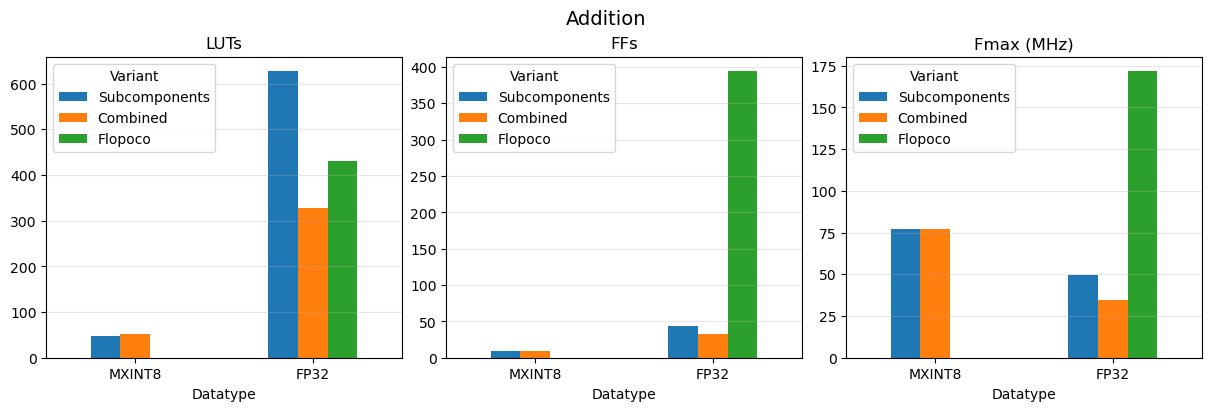

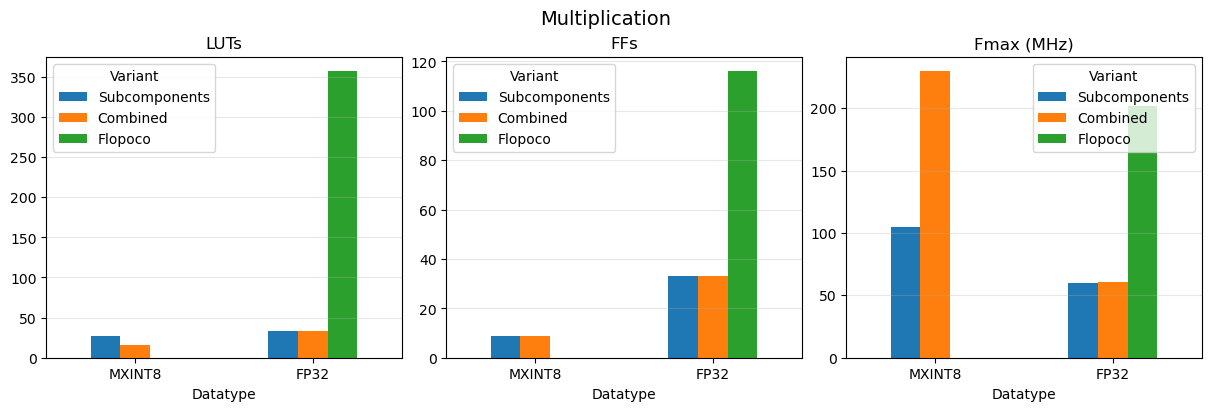

Constant/near-constant metrics across these runs:
                                     DSPs  BRAMs  Cycles
op             dtype  variant                           
Addition       FP32   Combined          0      0       1
                      Flopoco           0      0      -1
                      Subcomponents     0      0       1
               MXINT8 Combined          0      0       1
                      Subcomponents     0      0       1
Multiplication FP32   Combined          2      0       1
                      Flopoco           1      0      -1
                      Subcomponents     2      0       1
               MXINT8 Combined          0      0       1
                      Subcomponents     0      0       1


In [12]:
import matplotlib.pyplot as plt

metrics = [
    ("LUTs", "LUTs"),
    ("FFs", "FFs"),
    ("Fmax_MHz", "Fmax (MHz)"),
]

for op in ["Addition", "Multiplication"]:
    d = qor_df[(qor_df["op"] == op) & (qor_df["exists"])].copy()
    if d.empty:
        print(f"No QoR data for {op}")
        continue

    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), constrained_layout=True)

    for ax, (col, title) in zip(axes, metrics):
        p = d.pivot(index="dtype", columns="variant", values=col).reindex(["MXINT8", "FP32"])
        p = p.reindex(columns=[v for v in ["Subcomponents", "Combined", "Flopoco"] if v in p.columns])
        p.plot(kind="bar", ax=ax, rot=0)
        ax.set_title(title)
        ax.set_xlabel("Datatype")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="Variant")

    fig.suptitle(f"{op}", fontsize=14)
    plt.show()

print("Constant/near-constant metrics across these runs:")
print(qor_df.groupby(["op","dtype","variant"])[["DSPs","BRAMs","Cycles"]].first().sort_index())


# Grammar Selection Study Results

V1 (broad grammar, more productions/alternatives) vs V2 (tight sketch, mostly single-production NTs). Compares synthesis speed, hardware cost, and accuracy across MXINT8 and FP32 addition benchmarks.

Grammar Selection Study: V1 (broad) vs V2 (tight sketch)


,Benchmark,Grammar,Runs,Solve Rate,Mean Runtime (s),Mean Enum Terms,Mean LUTs,Mean Fmax (MHz),Exact Match %,Within Rel %,Grammar Productions,Branching NTs
0,FP32 Add,V1,3,100%,"6,176.0","7,738,221",80,33.5,0.0%,2.6%,51,14
1,FP32 Add,V2,3,100%,49.2,"22,631",641,133.3,90.9%,100.0%,17,2
2,MXINT8 Add,V1,3,100%,"2,683.7","847,479",57,56.3,—,26.8%,52,15
3,MXINT8 Add,V2,3,100%,12.3,510,61,39.3,—,77.8%,17,0



Per-run detail


,Label,Grammar Version,Repetition,Accepted Constraints,Total Constraints,Solver Runtime Seconds Total,Enum Count Primary Total,Luts,Fmax Mhz,Accuracy Exact Match,Within Rel Pct
0,FP32 Add,V1,1,7.0,30.0,6101.603068,6568677.0,80.0,33.542,0.0000,0.0254
1,FP32 Add,V1,2,8.0,30.0,6209.589632,8321181.0,80.0,33.542,0.0000,0.0263
2,FP32 Add,V1,3,8.0,30.0,6216.674319,8324805.0,80.0,33.542,0.0000,0.0266
3,FP32 Add,V2,1,30.0,30.0,58.141238,26071.0,624.0,133.316,0.9102,1.0000
4,FP32 Add,V2,2,30.0,30.0,29.856380,16878.0,676.0,133.316,0.9059,0.9996
5,FP32 Add,V2,3,30.0,30.0,59.576731,24945.0,624.0,133.316,0.9094,1.0000
6,MXINT8 Add,V1,1,6.0,30.0,2753.181629,757397.0,70.0,65.768,NaN,0.0890
7,MXINT8 Add,V1,2,5.0,30.0,2701.135582,1267819.0,53.0,46.990,NaN,0.4322
8,MXINT8 Add,V1,3,5.0,30.0,2596.780854,517221.0,47.0,56.208,NaN,0.2829
9,MXINT8 Add,V2,1,30.0,30.0,12.366730,510.0,61.0,39.287,NaN,0.7785


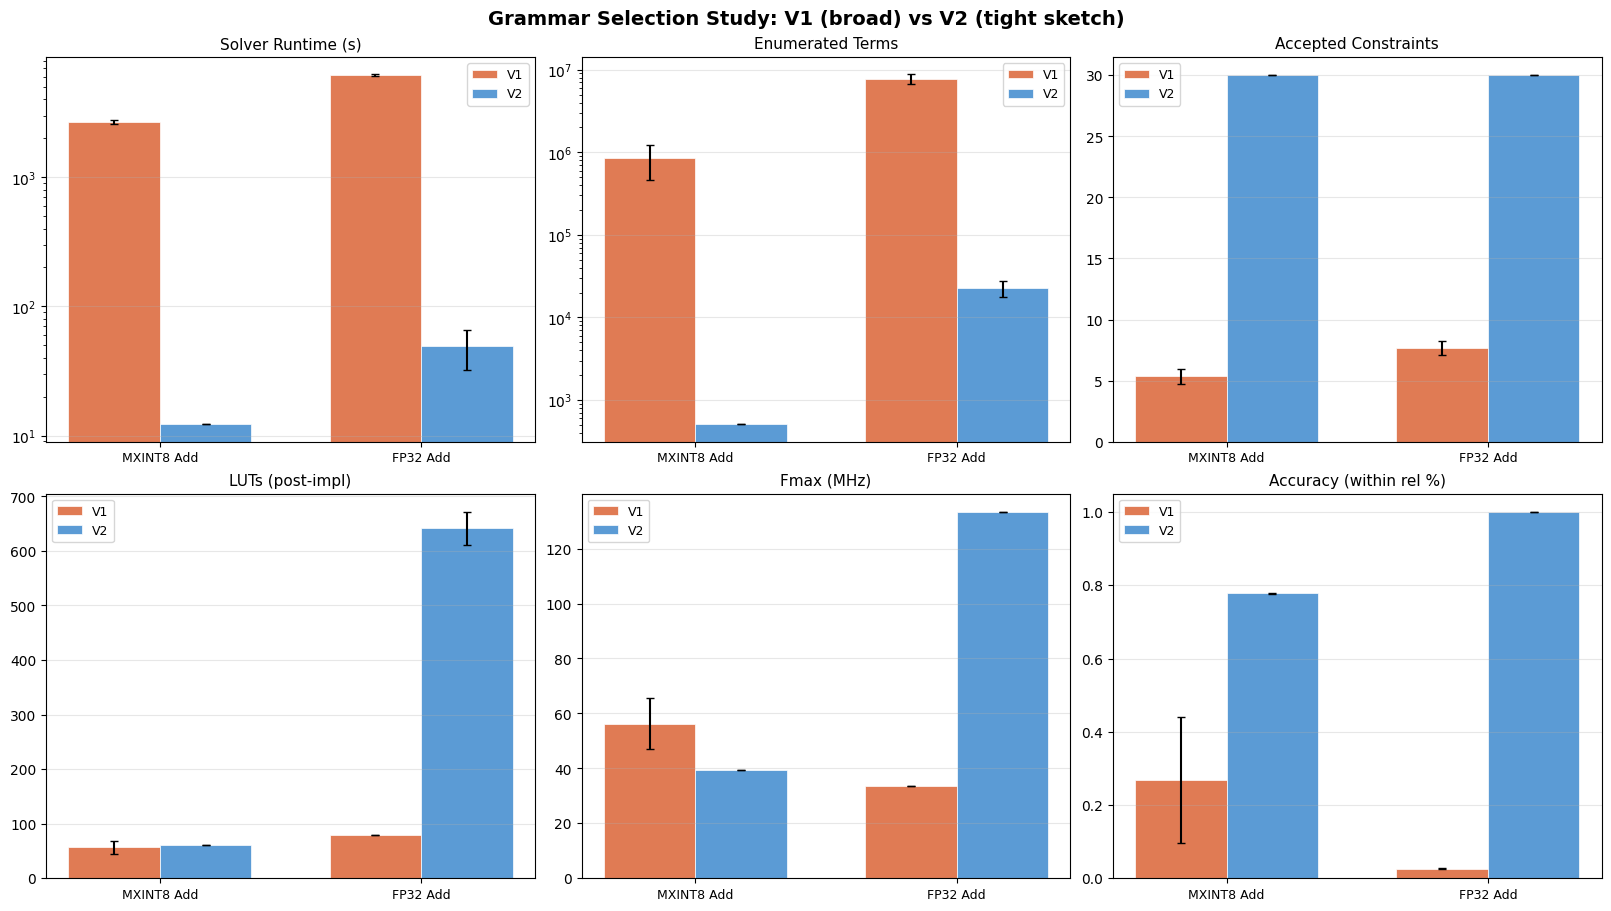


V2 vs V1 speedup


,Benchmark,V1 Runtime (s),V2 Runtime (s),Speedup,V1 Enum Terms,V2 Enum Terms,Enum Reduction
0,MXINT8 Add,"2,683.7",12.3,218x,"847,479",510,"1,662x"
1,FP32 Add,"6,176.0",49.2,126x,"7,738,221","22,631",342x


In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while root != root.parent:
        if (root / "results").exists() and (root / "src").exists():
            return root
        root = root.parent
    raise RuntimeError("Could not locate repo root")


ROOT = find_repo_root()
GS_DIR = ROOT / "results" / "grammar_selection"

# ── Load per-run data ──
runs_jsonl = GS_DIR / "runs.jsonl"
if not runs_jsonl.exists():
    raise FileNotFoundError(
        f"Grammar selection results not found at {runs_jsonl}.\n"
        "Run: python -m src.Experiments.grammar_selection_study ..."
    )

runs = [json.loads(line) for line in runs_jsonl.read_text().strip().split("\n")]
df = pd.DataFrame(runs)

# Clean up sentinel -1 values
for col in ["LUTs", "FFs", "Fmax_MHz", "accuracy_exact_match", "within_rel_pct",
            "solver_runtime_seconds_total", "enum_count_primary_total",
            "accepted_constraints", "total_constraints",
            "ulp_avg", "ulp_max", "ulp_p99",
            "abs_err_avg", "abs_err_max", "abs_err_p99"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df.loc[df[col] < 0, col] = np.nan

# ── Load aggregate summary ──
summary = json.loads((GS_DIR / "summary.json").read_text())
sdf = pd.DataFrame(summary)

# ── Pretty benchmark labels ──
label_map = {
    "mxint8_add_combined": "MXINT8 Add",
    "mxint8_mul_combined": "MXINT8 Mul",
    "fp32_add_combined": "FP32 Add",
    "fp32_mul_combined": "FP32 Mul",
}
df["label"] = df["benchmark"].map(label_map).fillna(df["benchmark"])
sdf["label"] = sdf["benchmark"].map(label_map).fillna(sdf["benchmark"])

# ══════════════════════════════════════════════════════════════════════
# Table 1: Aggregate summary
# ══════════════════════════════════════════════════════════════════════
summary_cols = {
    "label": "Benchmark",
    "grammar_version": "Grammar",
    "runs": "Runs",
    "solve_rate": "Solve Rate",
    "mean_runtime_seconds": "Mean Runtime (s)",
    "mean_enum_count": "Mean Enum Terms",
    "mean_LUTs": "Mean LUTs",
    "mean_Fmax_MHz": "Mean Fmax (MHz)",
    "mean_accuracy_exact_match": "Exact Match %",
    "mean_within_rel_pct": "Within Rel %",
    "total_productions": "Grammar Productions",
    "branching_nonterminals": "Branching NTs",
}
available = {k: v for k, v in summary_cols.items() if k in sdf.columns}
tbl = sdf[list(available.keys())].rename(columns=available).copy()

# Format for readability
if "Solve Rate" in tbl.columns:
    tbl["Solve Rate"] = tbl["Solve Rate"].map("{:.0%}".format)
if "Mean Runtime (s)" in tbl.columns:
    tbl["Mean Runtime (s)"] = tbl["Mean Runtime (s)"].map(lambda x: f"{x:,.1f}" if pd.notna(x) else "—")
if "Mean Enum Terms" in tbl.columns:
    tbl["Mean Enum Terms"] = tbl["Mean Enum Terms"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "—")
if "Mean LUTs" in tbl.columns:
    tbl["Mean LUTs"] = tbl["Mean LUTs"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "—")
if "Mean Fmax (MHz)" in tbl.columns:
    tbl["Mean Fmax (MHz)"] = tbl["Mean Fmax (MHz)"].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")
if "Exact Match %" in tbl.columns:
    tbl["Exact Match %"] = tbl["Exact Match %"].map(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "—")
if "Within Rel %" in tbl.columns:
    tbl["Within Rel %"] = tbl["Within Rel %"].map(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "—")

print("Grammar Selection Study: V1 (broad) vs V2 (tight sketch)")
print("=" * 80)
display(tbl)

# ══════════════════════════════════════════════════════════════════════
# Table 2: Per-run detail
# ══════════════════════════════════════════════════════════════════════
detail_cols = ["label", "grammar_version", "repetition",
               "accepted_constraints", "total_constraints",
               "solver_runtime_seconds_total", "enum_count_primary_total",
               "LUTs", "Fmax_MHz", "accuracy_exact_match", "within_rel_pct"]
detail_cols = [c for c in detail_cols if c in df.columns]
detail = df[detail_cols].sort_values(["label", "grammar_version", "repetition"]).reset_index(drop=True)
detail.columns = [c.replace("_", " ").title() for c in detail.columns]

print("\nPer-run detail")
print("=" * 80)
display(detail)

# ══════════════════════════════════════════════════════════════════════
# Charts
# ══════════════════════════════════════════════════════════════════════
benchmarks = df["label"].unique()
versions = ["V1", "V2"]
colours = {"V1": "#e07b54", "V2": "#5b9bd5"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

chart_specs = [
    ("solver_runtime_seconds_total", "Solver Runtime (s)", True),
    ("enum_count_primary_total", "Enumerated Terms", True),
    ("accepted_constraints", "Accepted Constraints", False),
    ("LUTs", "LUTs (post-impl)", False),
    ("Fmax_MHz", "Fmax (MHz)", False),
    ("within_rel_pct", "Accuracy (within rel %)", False),
]

for ax, (col, title, use_log) in zip(axes.flat, chart_specs):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    x = np.arange(len(benchmarks))
    width = 0.35
    for i, ver in enumerate(versions):
        subset = df[df["grammar_version"] == ver]
        means = [subset[subset["label"] == b][col].mean() for b in benchmarks]
        stds = [subset[subset["label"] == b][col].std() for b in benchmarks]
        ax.bar(x + i * width, means, width, yerr=stds, label=ver,
               color=colours[ver], capsize=3, edgecolor="white", linewidth=0.5)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(benchmarks, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    if use_log:
        ax.set_yscale("log")

fig.suptitle("Grammar Selection Study: V1 (broad) vs V2 (tight sketch)", fontsize=14, fontweight="bold")
plt.show()

# ══════════════════════════════════════════════════════════════════════
# Speedup / ratio summary
# ══════════════════════════════════════════════════════════════════════
ratio_rows = []
for bench in benchmarks:
    v1 = df[(df["label"] == bench) & (df["grammar_version"] == "V1")]
    v2 = df[(df["label"] == bench) & (df["grammar_version"] == "V2")]
    if v1.empty or v2.empty:
        continue
    rt1, rt2 = v1["solver_runtime_seconds_total"].mean(), v2["solver_runtime_seconds_total"].mean()
    en1, en2 = v1["enum_count_primary_total"].mean(), v2["enum_count_primary_total"].mean()
    ratio_rows.append({
        "Benchmark": bench,
        "V1 Runtime (s)": f"{rt1:,.1f}",
        "V2 Runtime (s)": f"{rt2:,.1f}",
        "Speedup": f"{rt1/rt2:,.0f}x" if rt2 > 0 else "—",
        "V1 Enum Terms": f"{en1:,.0f}",
        "V2 Enum Terms": f"{en2:,.0f}",
        "Enum Reduction": f"{en1/en2:,.0f}x" if en2 > 0 else "—",
    })

if ratio_rows:
    print("\nV2 vs V1 speedup")
    print("=" * 80)
    display(pd.DataFrame(ratio_rows))

# Bit-vector Search Experiments

The below cells try and optimise area by truncating the mantissa bit-widths keeping in mind accuracy within a % threshold. 

In [ ]:
# Synthesised bitvector sweep (FP32 + MXINT8 addition/multiplication)
# Runs all targets for each multiplier operand range mode and error tolerance.

import sys
import subprocess
from pathlib import Path


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while root != root.parent:
        if (root / "src" / "Experiments" / "bitvector_sweep.py").exists() and (root / "accuracy_tests").exists():
            return root
        root = root.parent
    raise RuntimeError("Could not locate repo root")


def tol_tag(value: float) -> str:
    return str(value).replace(".", "p")


ROOT = find_repo_root()
SEARCH_MODE = "sweep"   # "sweep" or "optuna"
OPTUNA_TRIALS = 24
COCOTB_MODES = ["small", "wide", "normal_full"]
REL_ERROR_PCTS = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]

runs = [(mode, tol) for mode in COCOTB_MODES for tol in REL_ERROR_PCTS]
failures = []

for run_idx, (mode, tol) in enumerate(runs, start=1):
    out_dir = ROOT / "results" / "sweeps" / "notebook" / "bitvector" / f"mode_{mode}__rel_{tol_tag(tol)}"
    cmd = [
        sys.executable,
        "-m",
        "src.Experiments.bitvector_sweep",
        "--all-targets",
        "--search",
        SEARCH_MODE,
        "--cocotb-mode",
        mode,
        "--rel-error-pct",
        str(tol),
        "--output-dir",
        str(out_dir),
    ]

    if SEARCH_MODE == "optuna":
        cmd += ["--optuna-trials", str(OPTUNA_TRIALS)]

    print(f"\n[{run_idx}/{len(runs)}] mode={mode} rel_error_pct={tol}")
    print("Command:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=ROOT)
    print("Return code:", proc.returncode)
    if proc.returncode != 0:
        failures.append((mode, tol, proc.returncode))

if failures:
    raise RuntimeError(f"Synthesised bitvector sweep failed for: {failures}")


In [ ]:
# FloPoCo bitvector sweep only (FP32 adder + multiplier)
# Runs both targets for each multiplier operand range mode and error tolerance.

import sys
import subprocess
from pathlib import Path


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while root != root.parent:
        if (root / "src" / "Experiments" / "flopoco_bitvector_sweep.py").exists() and (root / "accuracy_tests").exists():
            return root
        root = root.parent
    raise RuntimeError("Could not locate repo root")


def tol_tag(value: float) -> str:
    return str(value).replace(".", "p")


ROOT = find_repo_root()
SEARCH_MODE = "sweep"   # "sweep" or "optuna"
OPTUNA_TRIALS = 24
COCOTB_MODES = ["small", "wide", "normal_full"]
REL_ERROR_PCTS = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]

runs = [(mode, tol) for mode in COCOTB_MODES for tol in REL_ERROR_PCTS]
failures = []

for run_idx, (mode, tol) in enumerate(runs, start=1):
    out_dir = ROOT / "results" / "sweeps" / "notebook" / "flopoco_bitvector" / f"mode_{mode}__rel_{tol_tag(tol)}"
    cmd = [
        sys.executable,
        "-m",
        "src.Experiments.flopoco_bitvector_sweep",
        "--all-targets",
        "--search",
        SEARCH_MODE,
        "--cocotb-mode",
        mode,
        "--rel-error-pct",
        str(tol),
        "--output-dir",
        str(out_dir),
    ]

    if SEARCH_MODE == "optuna":
        cmd += ["--optuna-trials", str(OPTUNA_TRIALS)]

    print(f"\n[{run_idx}/{len(runs)}] mode={mode} rel_error_pct={tol}")
    print("Command:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=ROOT)
    print("Return code:", proc.returncode)
    if proc.returncode != 0:
        failures.append((mode, tol, proc.returncode))

if failures:
    raise RuntimeError(f"FloPoCo bitvector sweep failed for: {failures}")


In [ ]:
# Load bit-vector sweep outputs into a dataframe (for later plotting)

import re
from pathlib import Path

import pandas as pd


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while root != root.parent:
        if (root / "src" / "Experiments").exists() and (root / "results").exists():
            return root
        root = root.parent
    raise RuntimeError("Could not locate repo root")


def parse_mode_tol(tag: str) -> tuple[str, float]:
    # tag format expected: mode_<mode>__rel_<tol-with-p>
    m = re.match(r"^mode_(.+)__rel_([0-9p]+)$", tag)
    if not m:
        return ("unknown", float("nan"))
    mode = m.group(1)
    tol = float(m.group(2).replace("p", "."))
    return (mode, tol)


ROOT = find_repo_root()
SWEEP_ROOT = ROOT / "results" / "sweeps" / "notebook"

families = [
    ("synthesised", SWEEP_ROOT / "bitvector"),
    ("flopoco", SWEEP_ROOT / "flopoco_bitvector"),
]

frames = []
for family, base in families:
    if not base.exists():
        print(f"Skipping missing directory: {base}")
        continue

    for summary_csv in sorted(base.glob("mode_*__rel_*/summary_all_targets.csv")):
        run_dir = summary_csv.parent
        mode, rel_error_pct = parse_mode_tol(run_dir.name)

        df = pd.read_csv(summary_csv)
        df["family"] = family
        df["run_dir"] = str(run_dir)
        df["summary_csv"] = str(summary_csv)
        df["cocotb_mode_config"] = mode
        df["rel_error_pct_config"] = rel_error_pct
        frames.append(df)

if not frames:
    raise RuntimeError(f"No sweep summaries found under {SWEEP_ROOT}")

bv_results_df = pd.concat(frames, ignore_index=True)

# Useful numeric coercions for plotting later.
for col in [
    "mantissa_bits", "accuracy_exact_match", "within_rel_pct", "within_5pct_rel", "ulp_avg", "ulp_p99", "ulp_max",
    "abs_err_avg", "abs_err_p99", "abs_err_max", "LUTs", "FFs", "DSPs", "BRAMs", "Cycles", "Fmax_MHz", "area_score",
    "rel_error_pct_config",
]:
    if col in bv_results_df.columns:
        bv_results_df[col] = pd.to_numeric(bv_results_df[col], errors="coerce")

print(f"Loaded {len(bv_results_df)} rows from {len(frames)} run summaries")
print("Families:", sorted(bv_results_df["family"].dropna().unique()))
print("Modes:", sorted(bv_results_df["cocotb_mode_config"].dropna().unique()))
print("Tolerances (%):", sorted(bv_results_df["rel_error_pct_config"].dropna().unique()))

# Keep this display lightweight; use bv_results_df directly for violin plots.
bv_results_df.head(20)
